# Particle Filter

## Introduction

The **particle filter** is a nonparametric implementation of the Bayes filter.
Instead of a grid or a parametric form, the belief $\mathbf{bel}(x)$ is
represented by a set of $M$ weighted random samples (particles):

$$\mathbf{bel}(x) \approx \left\{ x_t^{[m]}, \; w_t^{[m]} \right\}_{m=1}^{M}$$

where each particle $x_t^{[m]}$ is a hypothesis about the robot's state, and
$w_t^{[m]}$ is its importance weight (how well it matches the measurements).

**Key advantages over histogram filters:**
- Particles concentrate in high-probability regions (adaptive resolution)
- Handles any distribution shape (multi-modal, non-Gaussian)
- Scales better to higher dimensions than grid-based methods

**Algorithm sketch:**
1. **Prediction**: Move each particle according to the motion model
2. **Update**: Re-weight each particle by the measurement likelihood
3. **Resample**: Draw new particles with probability proportional to weights

We use the same 1D corridor world as in previous tutorials: three doors at
1.5, 5.0, and 8.0 meters, with deterministic motion and trimodal likelihood.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.animation as animation
from IPython.display import HTML

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})
np.random.seed(42)

## World Setup (same as previous tutorials)

In [2]:
CORRIDOR_LENGTH = 10.0
DOOR_POSITIONS = np.array([1.5, 5.0, 8.0])
SENSOR_NOISE = 0.5
NUM_PARTICLES = 500

print(f"Corridor: 0-{CORRIDOR_LENGTH} m")
print(f"Doors at: {DOOR_POSITIONS}")
print(f"Particles: {NUM_PARTICLES}")

Corridor: 0-10.0 m
Doors at: [1.5 5.  8. ]
Particles: 500


---

## Particle Representation

The belief is a set of $M$ weighted particles $\{x^{[m]}, w^{[m]}\}_{m=1}^M$.
Visually, we plot each particle as a small vertical line at its position, with
height proportional to its weight.

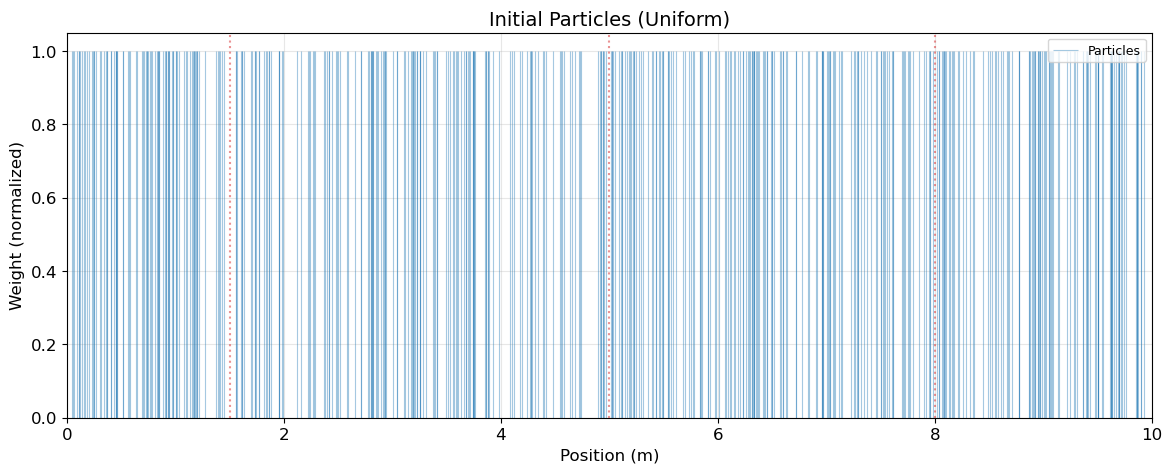

In [3]:
def plot_particles(ax, particles, weights, title="Particles", true_pos=None,
                   color='C0', alpha=0.4):
    """Plot particles as vertical stems with heights proportional to weights."""
    ax.clear()
    normalized_weights = weights / weights.max()
    ax.vlines(particles, 0, normalized_weights, colors=color, alpha=alpha,
              linewidth=0.8, label='Particles')

    for d in DOOR_POSITIONS:
        ax.axvline(d, color='C3', linestyle=':', linewidth=1.5, alpha=0.5)

    if true_pos is not None:
        ax.axvline(true_pos, color='C2', linewidth=3, linestyle='--',
                   label=f'True = {true_pos:.1f} m')

    ax.set_xlabel('Position (m)')
    ax.set_ylabel('Weight (normalized)')
    ax.set_title(title)
    ax.set_xlim(0, CORRIDOR_LENGTH)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)


# Initialize uniform particles
particles = np.random.uniform(0, CORRIDOR_LENGTH, NUM_PARTICLES)
weights = np.ones(NUM_PARTICLES) / NUM_PARTICLES
fig, ax = plt.subplots(figsize=(14, 5))
plot_particles(ax, particles, weights, title='Initial Particles (Uniform)')
plt.show()

## Motion Model

The robot moves right by $u_t = 0.5$ m per step. The **filter's motion model** is
deterministic (same as the discrete/histogram filter): each particle shifts right
by exactly $u_t$. The **actual** robot movement includes Gaussian noise for realism.

In [4]:
def predict(particles: np.ndarray, control: float) -> np.ndarray:
    """Deterministic prediction: shift particles right by `control` meters."""
    particles = particles + control
    particles = np.clip(particles, 0, CORRIDOR_LENGTH)
    return particles

## Measurement Model

The **trimodal likelihood** gives high weight to particles near any door:

$$p(z_t \mid x) = \sum_{i=1}^{3} \mathcal{N}(x \mid \text{door}_i, \; \sigma_z^2)$$

Three equal-height Gaussian peaks at the door positions. The weight of each
particle is proportional to the likelihood at its position.

In [5]:
def compute_weights(particles: np.ndarray) -> np.ndarray:
    """Compute importance weights using trimodal likelihood."""
    likelihood = np.zeros(len(particles))
    for door in DOOR_POSITIONS:
        likelihood += norm.pdf(particles, loc=door, scale=SENSOR_NOISE)
    weights = likelihood / likelihood.sum()

    closed_likelihood = 1 - 0.9 * likelihood
    closed_weights = closed_likelihood / closed_likelihood.sum()
    
    
    return weights, closed_weights

### Visualizing the Likelihood's Effect on Weights

Before running the full filter, let's see how particles get weighted by the
trimodal likelihood.

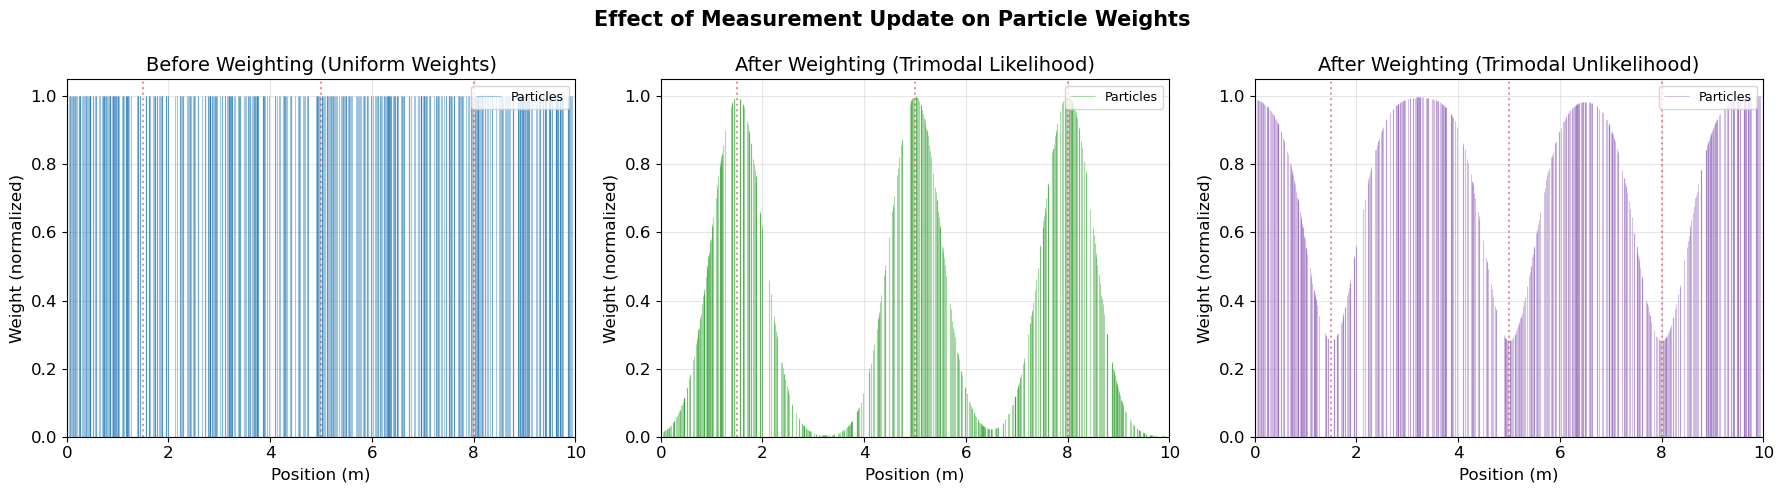

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Before weighting
plot_particles(ax1, particles, weights,
               title='Before Weighting (Uniform Weights)', color='C0')

# Compute and show weighted particles
weighted, closed_weighted = compute_weights(particles)
plot_particles(ax2, particles, weighted,
               title='After Weighting (Trimodal Likelihood)', color='C2')

plot_particles(ax3, particles, closed_weighted,
               title='After Weighting (Trimodal Unlikelihood)', color='C4')


fig.suptitle('Effect of Measurement Update on Particle Weights',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Resampling

After weighting, many particles have near-zero weight — they waste computation.
**Resampling** draws a new set of $M$ particles from the weighted set, with
probability proportional to each particle's weight. High-weight particles are
copied; low-weight particles are discarded.

We use **systematic resampling** (low variance, efficient):

In [7]:
def systematic_resample(particles: np.ndarray, weights: np.ndarray, close_weights: np.ndarray, sense_open: bool) -> np.ndarray:
    """Systematic resampling: draw M particles with prob proportional to weights."""
    M = len(particles)
    if sense_open == True:
        cumsum = np.cumsum(weights)
    else:
        cumsum = np.cumsum(close_weights)
    cumsum[-1] = 1.0  # avoid rounding errors
    
    # Systematic sampling: equally spaced starting points + random offset
    r = np.random.uniform(0, 1.0 / M)
    positions = r + np.arange(M) / M
    
    indices = np.searchsorted(cumsum, positions)
    indices = np.clip(indices, 0, M - 1)
    
    return particles[indices].copy()

### Visualizing Resampling

Particles with higher weight get duplicated; low-weight particles disappear.

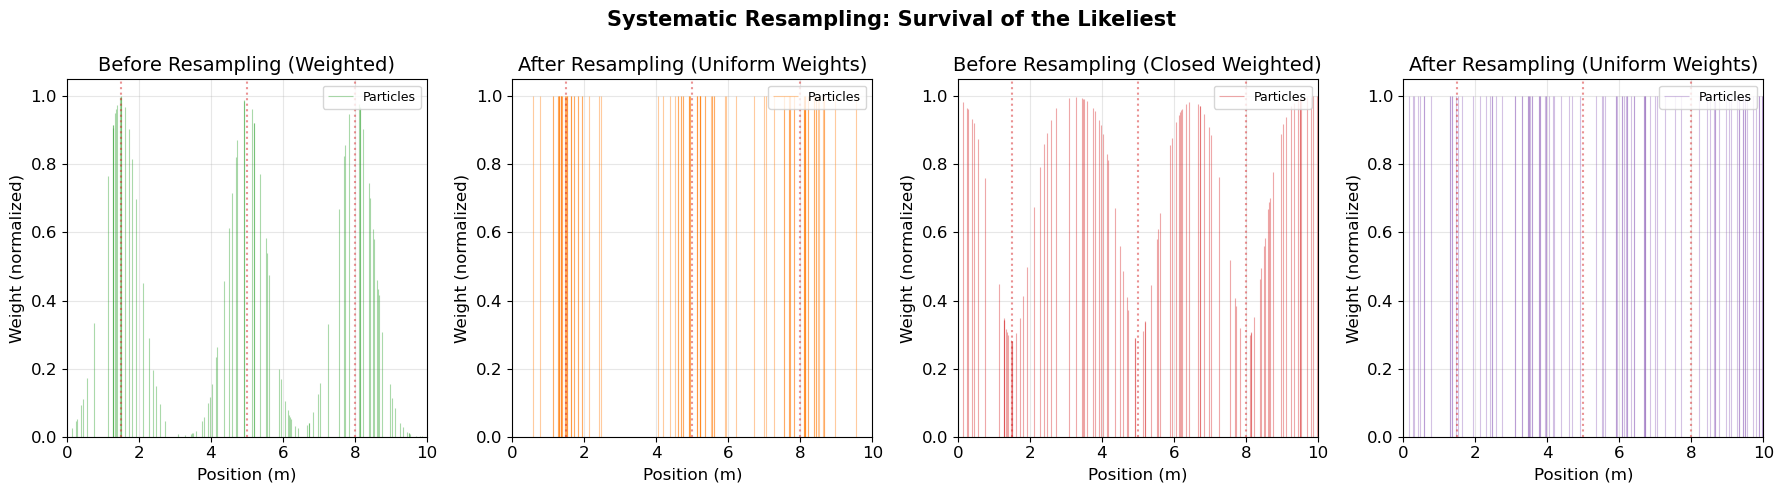

In [8]:
# Demonstrate resampling on a small set for clarity
demo_M = 100
demo_particles = np.random.uniform(0, CORRIDOR_LENGTH, demo_M)
demo_weights, demo_close_weights = compute_weights(demo_particles)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 5))

plot_particles(ax1, demo_particles, demo_weights,
               title='Before Resampling (Weighted)', color='C2')

demo_resampled = systematic_resample(demo_particles, demo_weights, demo_close_weights, True)
demo_resampled_weights = np.ones(demo_M) / demo_M
plot_particles(ax2, demo_resampled, demo_resampled_weights,
               title='After Resampling (Uniform Weights)', color='C1')

plot_particles(ax3, demo_particles, demo_close_weights,
               title='Before Resampling (Closed Weighted)', color='C3')

demo_resampled = systematic_resample(demo_particles, demo_weights, demo_close_weights, False)
demo_resampled_weights = np.ones(demo_M) / demo_M
plot_particles(ax4, demo_resampled, demo_resampled_weights,
               title='After Resampling (Uniform Weights)', color='C4')


fig.suptitle('Systematic Resampling: Survival of the Likeliest',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Full Particle Filter Algorithm

At each time step:

1. **Predict**: $x_t^{[m]} = x_{t-1}^{[m]} + u_t + \epsilon^{[m]}$ (deterministic shift)
2. **Update**: $w_t^{[m]} \propto p(z_t \mid x_t^{[m]})$
3. **Resample**: draw with replacement proportional to weights

In [13]:
def sense_open(state: float, door_positions, resolution):
    for door in door_positions:
        if abs(state - door) < 3 * resolution:
            return True
    return False

def particle_filter_step(particles, weights, control, is_open):
    """One full particle filter cycle: predict -> update -> resample."""
    # Predict
    particles = predict(particles, control)
    
    # Update (compute weights)
    weights, closed_weights = compute_weights(particles)
    
    # Resample
    particles = systematic_resample(particles, weights, closed_weights, is_open)
    weights = np.ones(len(particles)) / len(particles)
    
    return particles, weights


def run_particle_filter(n_steps: int = 20, motion_noise: float = 0.3) -> list:
    """Run the particle filter for n_steps."""
    particles = np.random.uniform(0, CORRIDOR_LENGTH, NUM_PARTICLES)
    weights = np.ones(NUM_PARTICLES) / NUM_PARTICLES
    true_pos = 0.5
    
    history = [{
        'step': 0,
        'true_pos': true_pos,
        'particles': particles.copy(),
        'weights': weights.copy(),
        'is_open': False
    }]
    
    for t in range(1, n_steps + 1):
        # Actual robot movement (noisy reality)
        true_pos += 0.5 + np.random.normal(0, motion_noise)
        true_pos = np.clip(true_pos, 0, CORRIDOR_LENGTH)
        is_open=sense_open(true_pos, DOOR_POSITIONS, 0.1)
        
        particles, weights = particle_filter_step(particles, weights, control=0.5, is_open=is_open)
        
        history.append({
            'step': t,
            'true_pos': true_pos,
            'particles': particles.copy(),
            'weights': weights.copy(),
            'is_open': is_open
        })
    
    return history


# Run
np.random.seed(42)
pf_history = run_particle_filter(n_steps=20)
print(f"Ran {len(pf_history) - 1} steps with {NUM_PARTICLES} particles.")
print(f"Final true position: {pf_history[-1]['true_pos']:.2f} m")
print(f"Mean particle position: {pf_history[-1]['particles'].mean():.2f} m")

Ran 20 steps with 500 particles.
Final true position: 10.00 m
Mean particle position: 10.00 m


### Particle Filter Evolution at Key Steps

Watch how particles initially spread everywhere gradually concentrate around
the true position as the filter cycles through predict-update-resample.

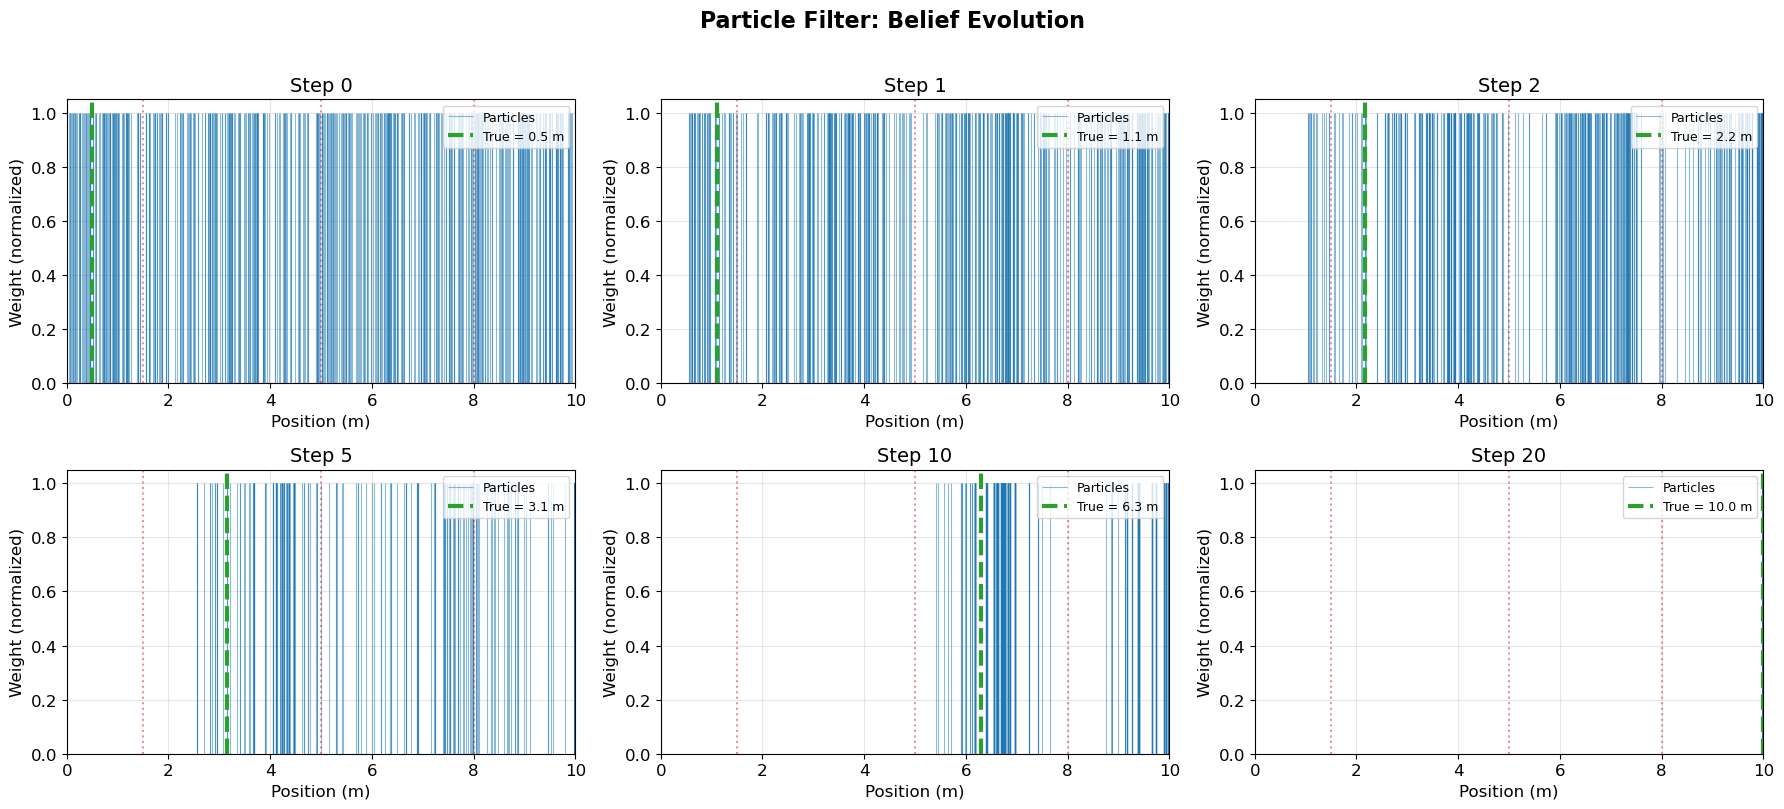

In [14]:
key_steps = [0, 1, 2, 5, 10, 20]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, step in enumerate(key_steps):
    h = pf_history[step]
    ax = axes[i]
    plot_particles(ax, h['particles'], h['weights'],
                   title=f'Step {step}', true_pos=h['true_pos'],
                   alpha=0.5)

fig.suptitle('Particle Filter: Belief Evolution',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Inside One Filter Cycle: Predict → Weight → Resample

Let's zoom into a single cycle to see each substep separately.

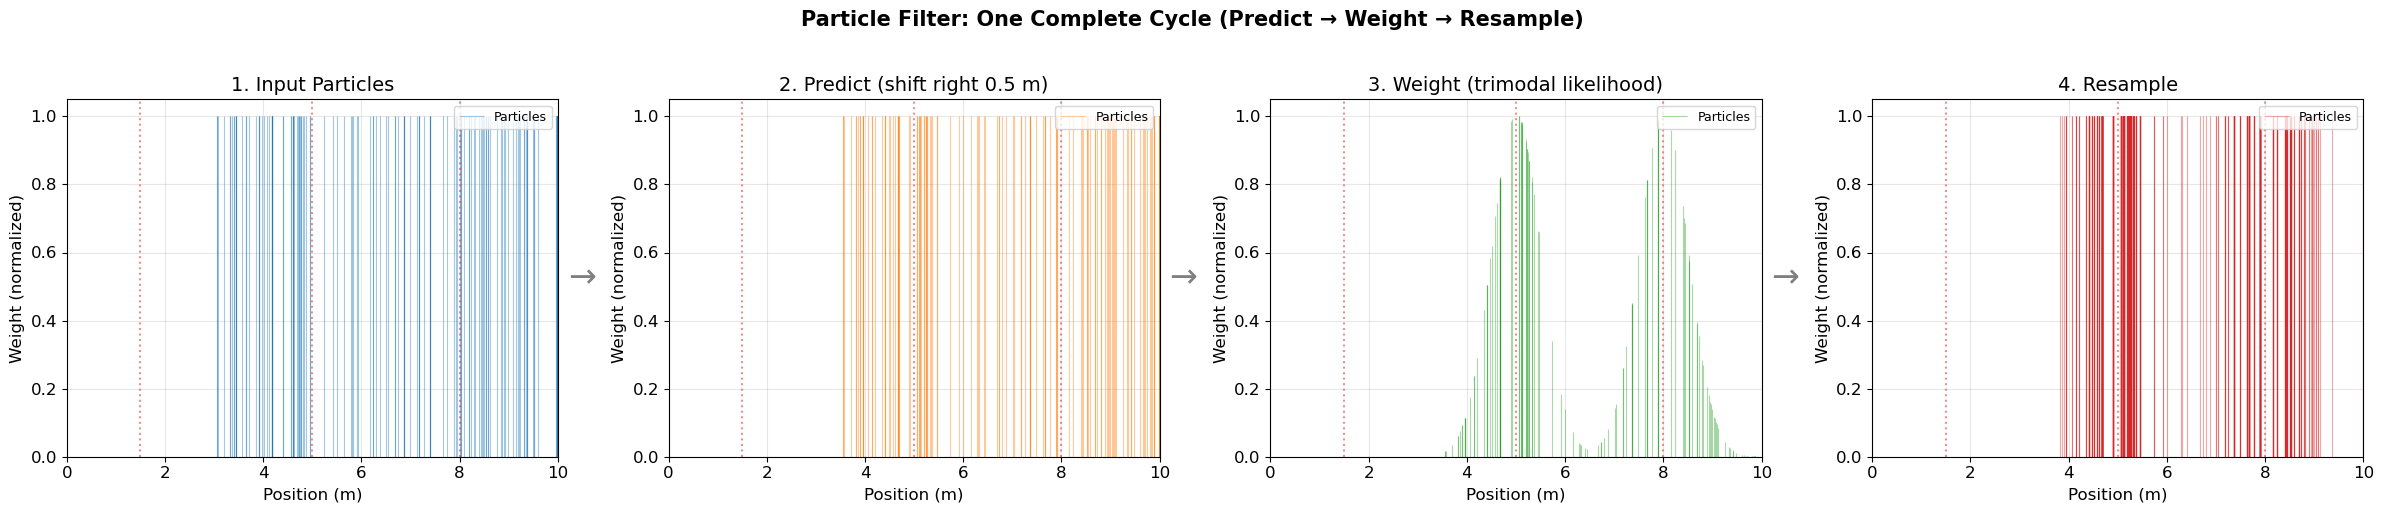

In [15]:
# Pick step 1 particles from history and manually show substeps
idx = -1
for i, step in enumerate(pf_history):
    if step['is_open'] == True:
        idx = i
        break


step1 = pf_history[idx]

# Get the particles BEFORE prediction (from step 0)
prev_particles = pf_history[idx - 1]['particles'].copy()

# Step 1: Predict (shift right)
predicted = predict(prev_particles, control=0.5)

# Step 2: Weight
w, w1 = compute_weights(predicted)

# Step 3: Resample
resampled = systematic_resample(predicted, w, w1, True)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

plot_particles(axes[0], prev_particles,
               np.ones(NUM_PARTICLES) / NUM_PARTICLES,
               title='1. Input Particles', color='C0')
plot_particles(axes[1], predicted,
               np.ones(NUM_PARTICLES) / NUM_PARTICLES,
               title='2. Predict (shift right 0.5 m)', color='C1')
plot_particles(axes[2], predicted, w,
               title='3. Weight (trimodal likelihood)', color='C2')
plot_particles(axes[3], resampled,
               np.ones(NUM_PARTICLES) / NUM_PARTICLES,
               title='4. Resample', color='C3')

for c in range(3):
    axes[c].annotate('\u2192', xy=(1.02, 0.5), xycoords='axes fraction',
                     fontsize=24, ha='left', va='center', color='gray')

fig.suptitle('Particle Filter: One Complete Cycle (Predict \u2192 Weight \u2192 Resample)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Interactive Particle Filter Animation

In [16]:
def animate_particle_filter():
    """Create an animation of the particle filter in action."""
    np.random.seed(123)
    
    particles = np.random.uniform(0, CORRIDOR_LENGTH, NUM_PARTICLES)
    weights = np.ones(NUM_PARTICLES) / NUM_PARTICLES
    true_pos = 1.0
    
    # Pre-compute all frames
    all_particles = [particles.copy()]
    all_true_pos = [true_pos]
    
    for _ in range(30):
        true_pos += 0.3 + np.random.normal(0, 0.1)
        true_pos = np.clip(true_pos, 0, CORRIDOR_LENGTH)

        is_open=sense_open(true_pos, DOOR_POSITIONS, 0.1)
        
        particles, weights = particle_filter_step(particles, weights, control=0.3, is_open=is_open)
        all_particles.append(particles.copy())
        all_true_pos.append(true_pos)
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    def draw_frame(frame):
        ax.clear()
        pts = all_particles[frame]
        ax.vlines(pts, 0, 0.8, colors='C0', linewidth=0.5, alpha=0.6)
        ax.plot(pts, np.ones_like(pts) * 0.8, 'o', color='C0', markersize=3, alpha=0.6)
        for d in DOOR_POSITIONS:
            ax.axvline(d, color='C3', linestyle=':', linewidth=1.5, alpha=0.5)
        ax.axvline(all_true_pos[frame], color='C2', linewidth=3, linestyle='--',
                   label='True position')
        ax.set_xlim(0, CORRIDOR_LENGTH)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Position (m)')
        ax.set_ylabel('Particles')
        ax.set_title(f'Particle Filter: Step {frame} | True: {all_true_pos[frame]:.2f} m')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    anim = animation.FuncAnimation(fig, draw_frame, frames=len(all_particles),
                                   interval=250, blit=False, repeat=True)
    plt.close()
    return anim


anim = animate_particle_filter()
HTML(anim.to_jshtml())

---

## Summary

### Particle Filter
- Represent belief as $M$ weighted particles $\{x^{[m]}, w^{[m]}\}_{m=1}^M$
- **Predict**: Move each particle according to the motion model
- **Update**: Re-weight particles by measurement likelihood
- **Resample**: Draw new particles proportional to weights (survival of the fittest)

### Comparison with Discrete / Histogram Filters
| Aspect | Discrete/Histogram | Particle Filter |
|--------|-------------------|-----------------|
| Representation | Fixed grid of bins | Random samples |
| Resolution | Uniform (static or dynamic) | Adaptive (more particles where needed) |
| Computational cost | $O(K)$ per step | $O(M)$ per step |
| High dimensions | Exponential cost | Polynomial cost |
| Deterministic | Yes | Monte Carlo (stochastic) |

### What's Next?
- **Importance sampling theory** — why this works as a Bayes filter
- **Resampling variants** — multinomial, stratified, residual
- **2D particle filters** — localization in planar environments
- **Particle filter SLAM** — simultaneous localization and mapping